<a href="https://www.kaggle.com/code/sonawanelalitsunil/healthy-eating-insights-eda-ml-99-75?scriptVersionId=265018211" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/healthy-eating-dataset/healthy_eating_dataset.csv


## Title:
Healthy Eating Insights 
## Description:
This project analyzes dietary patterns and nutritional habits to understand factors influencing healthy eating. Using a dataset of food consumption and lifestyle metrics, we perform exploratory data analysis (EDA) to visualize trends and correlations. Machine learning techniques, specifically the Random Forest algorithm, are applied to predict healthy eating behaviors based on individual features. The project highlights key determinants of a balanced diet, evaluates model performance, and provides actionable insights to promote healthier dietary choices.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/healthy-eating-dataset/healthy_eating_dataset.csv")

In [3]:
df.head()

,meal_id,meal_name,cuisine,meal_type,diet_type,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,cooking_method,prep_time_min,cook_time_min,rating,is_healthy,image_url
0,1,Kid Pasta,Indian,Lunch,Keto,737,52.4,43.9,34.3,16.8,42.9,2079,91,206,Grilled,47,56,4.4,0,https://example.com/images/meal_1.jpg
1,2,Husband Rice,Mexican,Lunch,Paleo,182,74.7,144.4,0.1,22.3,38.6,423,7,317,Roasted,51,34,2.4,0,https://example.com/images/meal_2.jpg
2,3,Activity Rice,Indian,Snack,Paleo,881,52.9,97.3,18.8,20.0,37.5,2383,209,395,Boiled,58,29,4.3,0,https://example.com/images/meal_3.jpg
3,4,Another Salad,Mexican,Snack,Keto,427,17.5,73.1,7.6,9.8,41.7,846,107,499,Grilled,14,81,4.6,0,https://example.com/images/meal_4.jpg
4,5,Quite Stew,Thai,Lunch,Vegan,210,51.6,104.3,26.3,24.8,18.2,1460,42,486,Raw,47,105,4.3,0,https://example.com/images/meal_5.jpg


In [4]:
df.tail()

,meal_id,meal_name,cuisine,meal_type,diet_type,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,cooking_method,prep_time_min,cook_time_min,rating,is_healthy,image_url
1995,1996,Admit Curry,Mediterranean,Lunch,Keto,163,16.0,48.1,3.6,26.6,40.9,984,155,447,Grilled,37,71,1.3,0,https://example.com/images/meal_1996.jpg
1996,1997,Majority Sandwich,Mediterranean,Snack,Balanced,177,79.5,24.4,12.9,27.1,13.6,1612,271,211,Roasted,60,9,1.5,1,https://example.com/images/meal_1997.jpg
1997,1998,Speech Sandwich,Indian,Lunch,Balanced,419,31.8,42.9,42.7,9.4,29.1,1192,201,248,Roasted,50,95,3.8,0,https://example.com/images/meal_1998.jpg
1998,1999,Away Rice,American,Dinner,Keto,1123,6.9,119.6,23.1,0.8,17.7,360,146,342,Fried,15,20,4.2,0,https://example.com/images/meal_1999.jpg
1999,2000,List Pasta,Indian,Snack,Balanced,341,51.5,77.7,0.1,8.2,9.0,398,91,236,Fried,53,100,1.9,1,https://example.com/images/meal_2000.jpg


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   meal_id         2000 non-null   int64  
 1   meal_name       2000 non-null   object 
 2   cuisine         2000 non-null   object 
 3   meal_type       2000 non-null   object 
 4   diet_type       2000 non-null   object 
 5   calories        2000 non-null   int64  
 6   protein_g       2000 non-null   float64
 7   carbs_g         2000 non-null   float64
 8   fat_g           2000 non-null   float64
 9   fiber_g         2000 non-null   float64
 10  sugar_g         2000 non-null   float64
 11  sodium_mg       2000 non-null   int64  
 12  cholesterol_mg  2000 non-null   int64  
 13  serving_size_g  2000 non-null   int64  
 14  cooking_method  2000 non-null   object 
 15  prep_time_min   2000 non-null   int64  
 16  cook_time_min   2000 non-null   int64  
 17  rating          2000 non-null   f

In [6]:
df.describe()

,meal_id,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,prep_time_min,cook_time_min,rating,is_healthy
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,650.061500,42.863750,75.924250,30.065300,15.245800,24.60230,1257.316000,150.459500,302.620000,33.354500,61.507000,2.984250,0.093500
std,577.494589,315.419877,21.992887,42.749671,17.573243,8.754933,14.48074,709.587762,87.940048,115.489643,16.476941,33.559411,1.164884,0.291205
min,1.000000,100.000000,5.000000,0.000000,0.000000,0.000000,0.00000,50.000000,0.000000,100.000000,5.000000,5.000000,1.000000,0.000000
25%,500.750000,372.000000,23.600000,39.200000,14.800000,7.600000,12.00000,647.500000,72.000000,207.000000,19.000000,33.000000,2.000000,0.000000
50%,1000.500000,648.000000,43.600000,75.950000,30.300000,15.150000,24.75000,1273.000000,150.000000,302.000000,34.000000,61.000000,3.000000,0.000000
75%,1500.250000,914.500000,61.900000,113.025000,45.200000,23.200000,37.20000,1854.500000,228.000000,402.000000,48.000000,90.000000,4.000000,0.000000
max,2000.000000,1200.000000,79.900000,150.000000,60.000000,30.000000,50.00000,2499.000000,300.000000,500.000000,60.000000,120.000000,5.000000,1.000000


In [7]:
df.dtypes

meal_id             int64
meal_name          object
cuisine            object
meal_type          object
diet_type          object
calories            int64
protein_g         float64
carbs_g           float64
fat_g             float64
fiber_g           float64
sugar_g           float64
sodium_mg           int64
cholesterol_mg      int64
serving_size_g      int64
cooking_method     object
prep_time_min       int64
cook_time_min       int64
rating            float64
is_healthy          int64
image_url          object
dtype: object

In [8]:
df.shape

(2000, 20)

In [9]:
df.isnull().sum()

meal_id           0
meal_name         0
cuisine           0
meal_type         0
diet_type         0
calories          0
protein_g         0
carbs_g           0
fat_g             0
fiber_g           0
sugar_g           0
sodium_mg         0
cholesterol_mg    0
serving_size_g    0
cooking_method    0
prep_time_min     0
cook_time_min     0
rating            0
is_healthy        0
image_url         0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.nunique()

meal_id           2000
meal_name         1750
cuisine              8
meal_type            4
diet_type            6
calories           923
protein_g          700
carbs_g           1120
fat_g              581
fiber_g            300
sugar_g            496
sodium_mg         1354
cholesterol_mg     300
serving_size_g     398
cooking_method       7
prep_time_min       56
cook_time_min      116
rating              41
is_healthy           2
image_url         2000
dtype: int64

In [12]:
df.describe().loc[['mean','max', 'min']]

,meal_id,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,prep_time_min,cook_time_min,rating,is_healthy
mean,1000.5,650.0615,42.86375,75.92425,30.0653,15.2458,24.6023,1257.316,150.4595,302.62,33.3545,61.507,2.98425,0.0935
max,2000.0,1200.0000,79.90000,150.00000,60.0000,30.0000,50.0000,2499.000,300.0000,500.00,60.0000,120.000,5.00000,1.0000
min,1.0,100.0000,5.00000,0.00000,0.0000,0.0000,0.0000,50.000,0.0000,100.00,5.0000,5.000,1.00000,0.0000


In [13]:
df.columns

Index(['meal_id', 'meal_name', 'cuisine', 'meal_type', 'diet_type', 'calories',
       'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'sugar_g', 'sodium_mg',
       'cholesterol_mg', 'serving_size_g', 'cooking_method', 'prep_time_min',
       'cook_time_min', 'rating', 'is_healthy', 'image_url'],
      dtype='object')

## Data visualizations

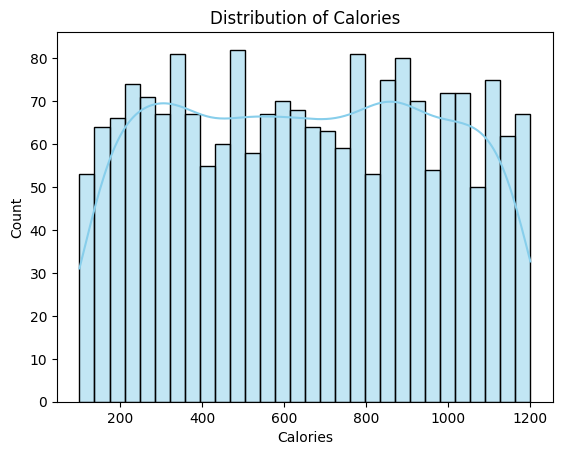

In [14]:
plt.figure()
sns.histplot(df['calories'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Calories')
plt.xlabel('Calories')
plt.ylabel('Count')
plt.show()

<Figure size 640x480 with 0 Axes>

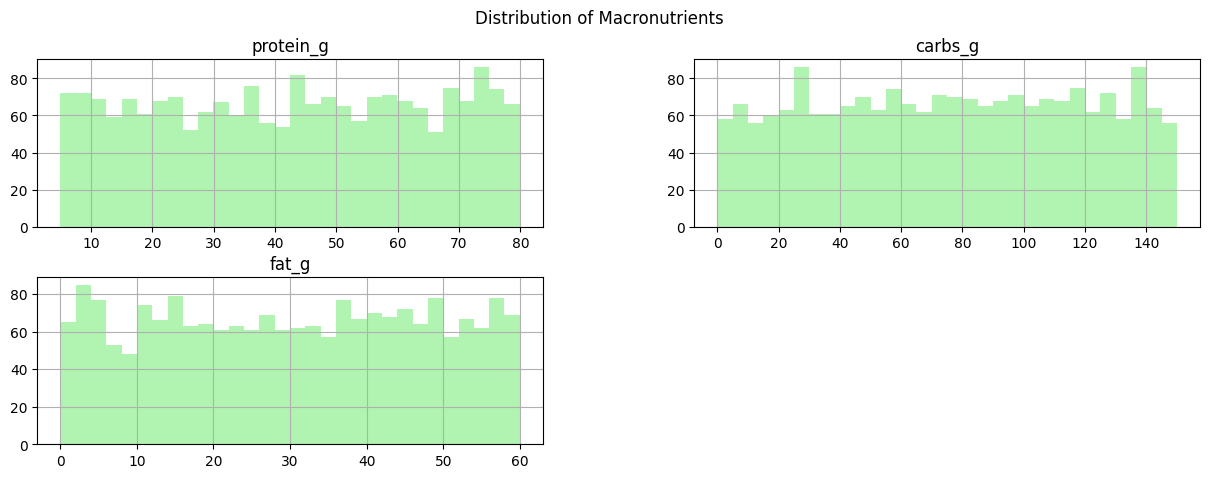

In [15]:
plt.figure()
df[['protein_g', 'carbs_g', 'fat_g']].hist(bins=30, color='lightgreen', alpha=0.7, figsize=(15,5))
plt.suptitle('Distribution of Macronutrients')
plt.show()

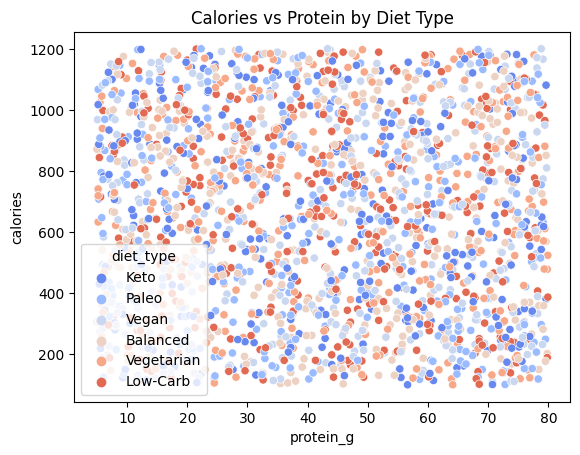

In [16]:
plt.figure()
sns.scatterplot(data=df, x='protein_g', y='calories', hue='diet_type', palette='coolwarm')
plt.title('Calories vs Protein by Diet Type')
plt.show()


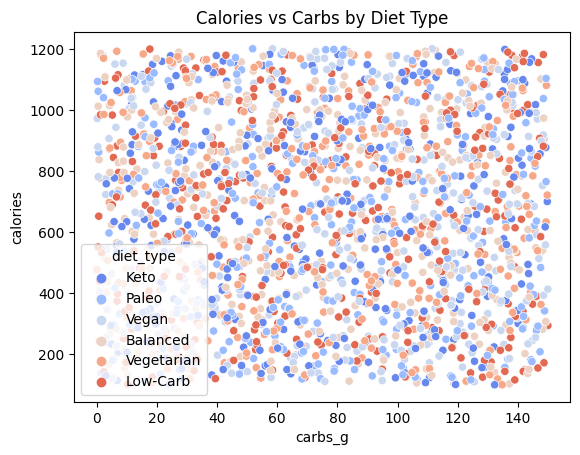

In [17]:
plt.figure()
sns.scatterplot(data=df, x='carbs_g', y='calories', hue='diet_type', palette='coolwarm')
plt.title('Calories vs Carbs by Diet Type')
plt.show()

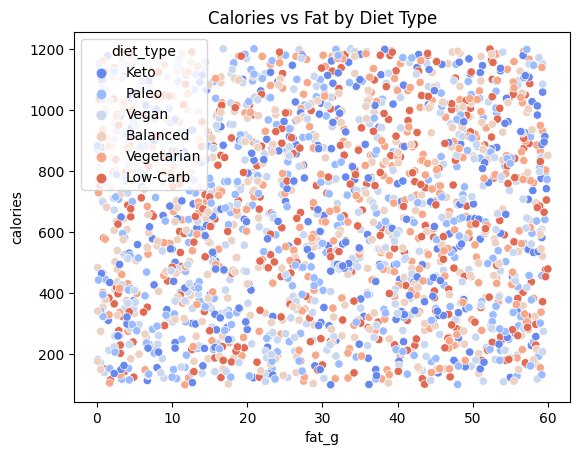

In [18]:
plt.figure()
sns.scatterplot(data=df, x='fat_g', y='calories', hue='diet_type', palette='coolwarm')
plt.title('Calories vs Fat by Diet Type')
plt.show()

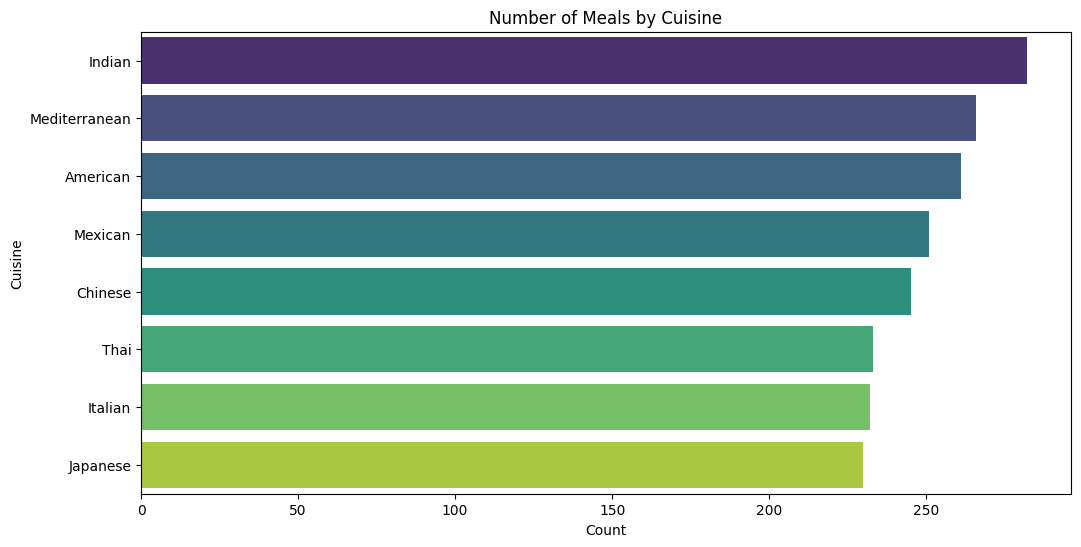

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(y='cuisine', data=df, order=df['cuisine'].value_counts().index, palette='viridis')
plt.title('Number of Meals by Cuisine')
plt.xlabel('Count')
plt.ylabel('Cuisine')
plt.show()


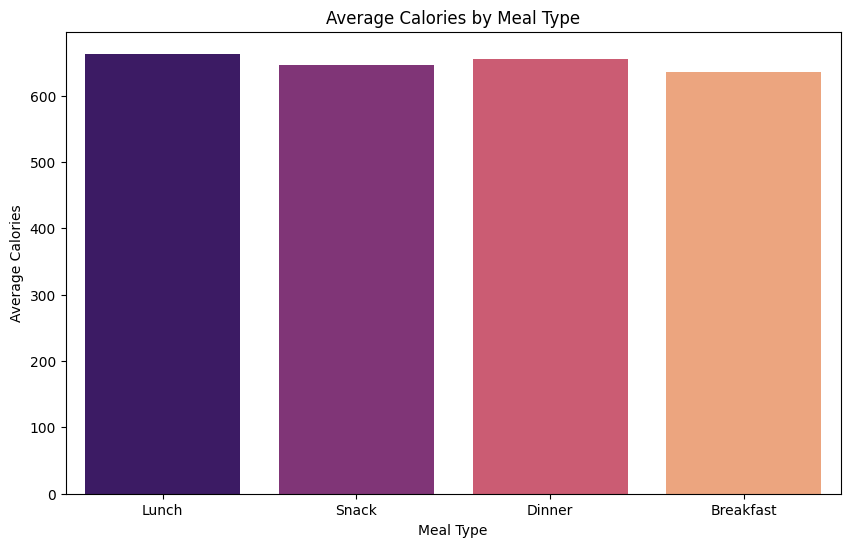

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x='meal_type', y='calories', data=df, palette='magma', ci=None)
plt.title('Average Calories by Meal Type')
plt.xlabel('Meal Type')
plt.ylabel('Average Calories')
plt.show()

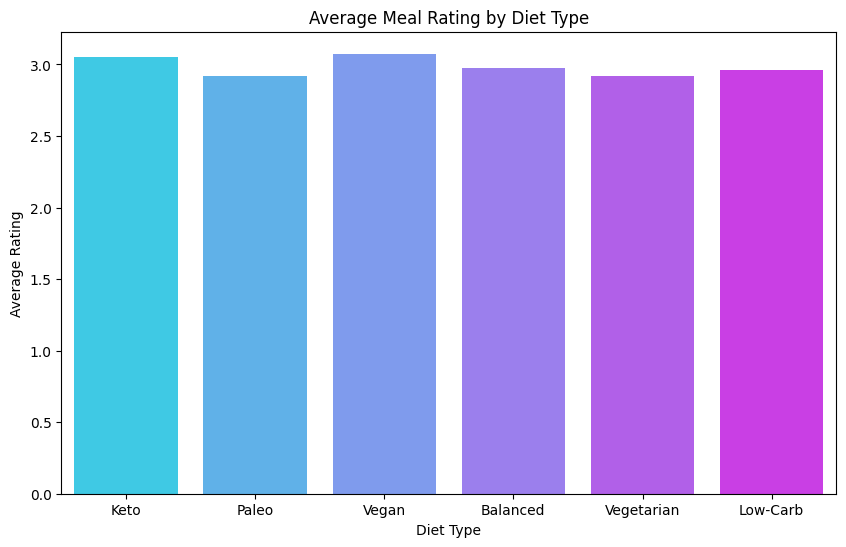

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(x='diet_type', y='rating', data=df, palette='cool', ci=None)
plt.title('Average Meal Rating by Diet Type')
plt.xlabel('Diet Type')
plt.ylabel('Average Rating')
plt.show()

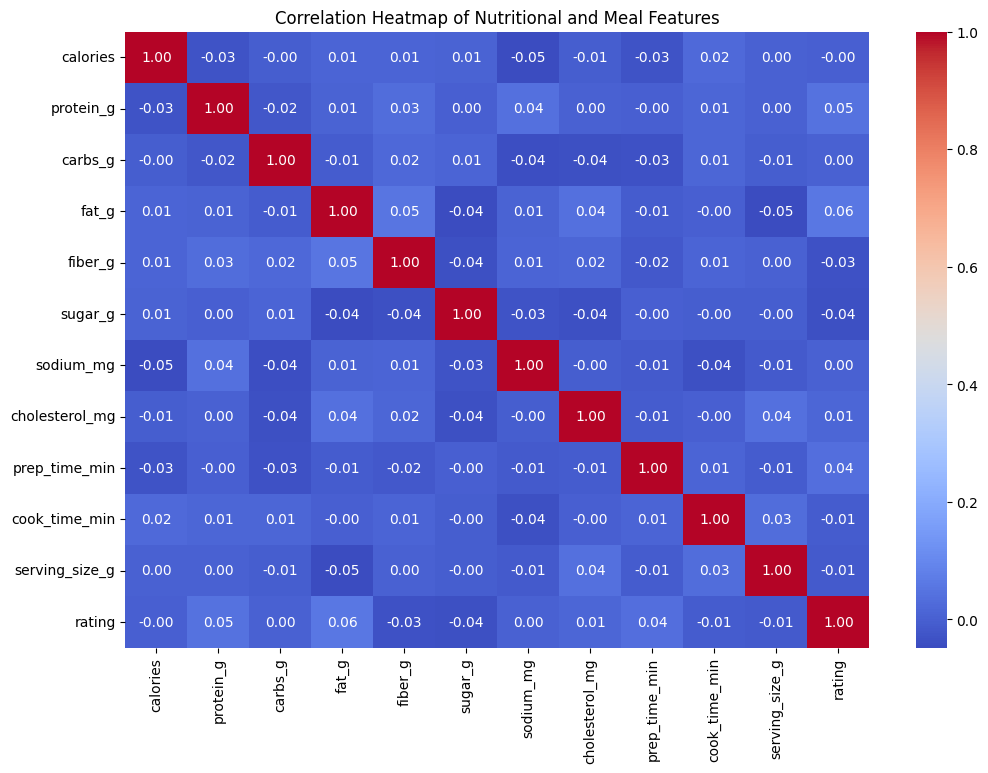

In [22]:
plt.figure(figsize=(12,8))
numeric_features = ['calories', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'prep_time_min', 'cook_time_min', 'serving_size_g', 'rating']
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Nutritional and Meal Features')
plt.show()

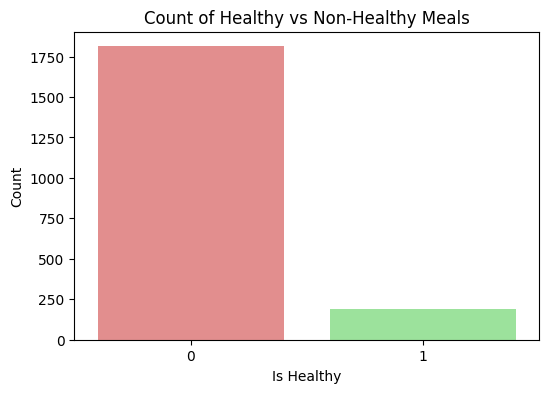

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_healthy', data=df, palette=['lightcoral','lightgreen'])
plt.title('Count of Healthy vs Non-Healthy Meals')
plt.xlabel('Is Healthy')
plt.ylabel('Count')
plt.show()

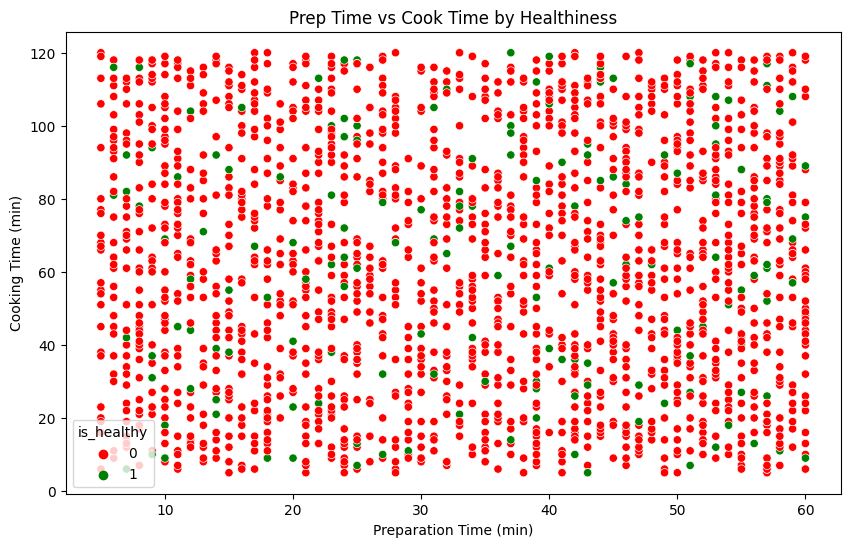

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='prep_time_min', y='cook_time_min', hue='is_healthy', data=df, palette=['red','green'])
plt.title('Prep Time vs Cook Time by Healthiness')
plt.xlabel('Preparation Time (min)')
plt.ylabel('Cooking Time (min)')
plt.show()

## ML Algorithms

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [26]:
categorical_cols = ['meal_name', 'cuisine', 'meal_type', 'diet_type', 'cooking_method']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le 

In [27]:
X = df.drop(['meal_id', 'image_url', 'is_healthy'], axis=1)
y = df['is_healthy']


In [28]:
# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# 4. Define ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Classifier": SVC()
}

In [30]:
accuracy_dict = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    accuracy_dict[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.2f}%")

Logistic Regression Accuracy: 94.25%
Decision Tree Accuracy: 99.50%
Random Forest Accuracy: 99.50%
Gradient Boosting Accuracy: 99.75%
K-Nearest Neighbors Accuracy: 88.50%
Support Vector Classifier Accuracy: 90.75%


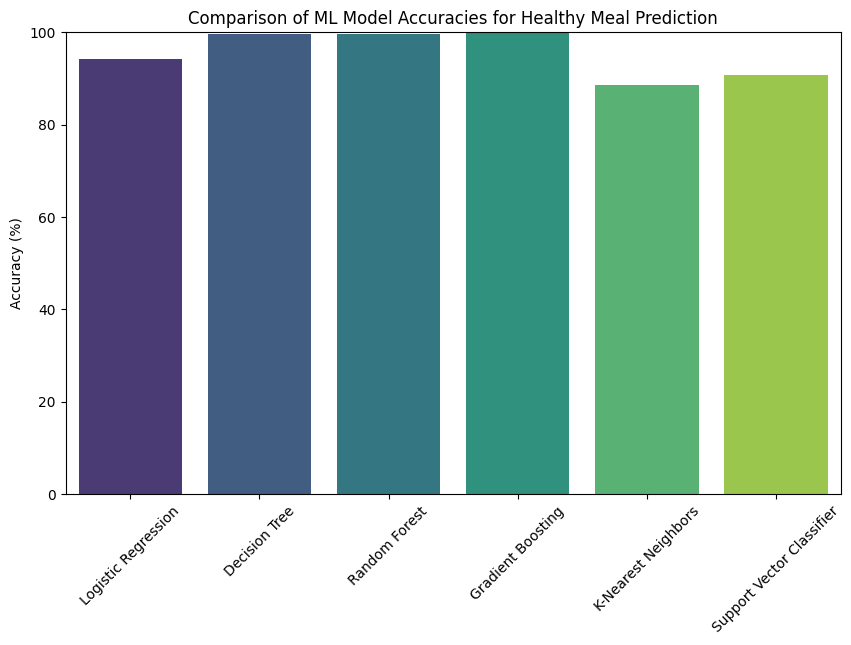

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='viridis')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.title('Comparison of ML Model Accuracies for Healthy Meal Prediction')
plt.xticks(rotation=45)
plt.show()

## Thank you..pls upvote!!!